# Movie Recommendation System (Collaborative Filtering)

**Project Description:** This model recommends movies to users by analyzing past ratings, constructing a user-item rating matrix, and identifying similar movies based on user preferences.

**Algorithm:** It utilizes the **K-Nearest Neighbors (KNN)** algorithm with Cosine Similarity, which computes the distance between movie vectors to find the closest matches in the rating space.

Step 1: Import the Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline

Step 2: Import the Datasets

In [3]:
movies_df = pd.read_csv("./Dataset/movies.csv")
ratings_df = pd.read_csv("./Dataset/ratings.csv")

print(movies_df.shape)
print(ratings_df.shape)

(9742, 3)
(100836, 4)


Step 3: Merge the Datasets

In [4]:
df = pd.merge(movies_df, ratings_df, on="movieId")
df.shape

(100836, 6)

In [5]:
df.head()

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,1106635946
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,1510577970
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,1305696483


Step 4: Filter by Popularity Threshold

In [6]:
movie_rating_count = df.groupby('title')['rating'].count().reset_index()
movie_rating_count.rename(columns={'rating': 'total_ratings'}, inplace=True)

df_with_counts = pd.merge(df, movie_rating_count, on='title')

popularity_threshold = 10
filtered_df = df_with_counts[df_with_counts['total_ratings'] >= popularity_threshold]

print(f"Original Dataset Rows: {df.shape[0]}")
print(f"Filtered Dataset Rows (movies with >= {popularity_threshold} ratings): {filtered_df.shape[0]}")
print(f"Unique movies left: {filtered_df['title'].nunique()}")

Original Dataset Rows: 100836
Filtered Dataset Rows (movies with >= 10 ratings): 81120
Unique movies left: 2269


Step 5: Create a Pivot Table

In [16]:
movie_pivot = filtered_df.pivot_table(index='title', columns='userId', values='rating').fillna(0)
movie_pivot.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
"'burbs, The (1989)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
(500) Days of Summer (2009),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.5
10 Cloverfield Lane (2016),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
10 Things I Hate About You (1999),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0
"10,000 BC (2008)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Step 6: Convert to Sparse Matrix

In [8]:
from scipy.sparse import csr_matrix

movie_sparse = csr_matrix(movie_pivot.values)

Step 7: Train the KNN Model

In [9]:
from sklearn.neighbors import NearestNeighbors

model_knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=6)
model_knn.fit(movie_sparse)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


Step 8: Define the Recommendation Function

In [ ]:
def recommend_movie(movie_search_name):
    search_query = movie_search_name.lower().strip()
    all_titles = movie_pivot.index.tolist()
    matched_titles = [title for title in all_titles if search_query in title.lower()]
    
    if not matched_titles:
        print(f"❌ Could not find any movies matching '{movie_search_name}' in our database.")
        print("Tip: Try typing just a single main keyword (e.g., 'Matrix' instead of 'The Matrix (1999)').")
        return

    target_movie = matched_titles[0]
    print(f"Target Selected: '{target_movie}'")
    print("==================================================")
    
    movie_idx = movie_pivot.index.get_loc(target_movie)
    distances, indices = model_knn.kneighbors(movie_pivot.iloc[movie_idx, :].values.reshape(1, -1), n_neighbors=6)
    
    distances = distances.flatten()
    indices = indices.flatten()
    
    print(f"Top 5 Recommendations for you:")
    print("--------------------------------------------------")
    
    rank = 1
    for i in range(1, len(indices)):
        rec_title = movie_pivot.index[indices[i]]
        similarity_score = (1 - distances[i]) * 100
        print(f"{rank}. {rec_title} (Match Confidence: {similarity_score:.2f}%)")
        rank += 1
        
    print("==================================================\n\n")

Step 9: Test Movie Recommendations

In [11]:
recommend_movie("Matrix")

Target Selected: 'Animatrix, The (2003)'
Top 5 Recommendations for you:
--------------------------------------------------
1. Scanner Darkly, A (2006) (Match Confidence: 51.35%)
2. Lemony Snicket's A Series of Unfortunate Events (2004) (Match Confidence: 51.13%)
3. Fountain, The (2006) (Match Confidence: 50.20%)
4. Hitchhiker's Guide to the Galaxy, The (2005) (Match Confidence: 48.96%)
5. Scott Pilgrim vs. the World (2010) (Match Confidence: 47.97%)




In [12]:
recommend_movie("Toy Story")

Target Selected: 'Toy Story (1995)'
Top 5 Recommendations for you:
--------------------------------------------------
1. Toy Story 2 (1999) (Match Confidence: 57.26%)
2. Jurassic Park (1993) (Match Confidence: 56.56%)
3. Independence Day (a.k.a. ID4) (1996) (Match Confidence: 56.43%)
4. Star Wars: Episode IV - A New Hope (1977) (Match Confidence: 55.74%)
5. Forrest Gump (1994) (Match Confidence: 54.71%)




In [13]:
recommend_movie("Inception")

Target Selected: 'Inception (2010)'
Top 5 Recommendations for you:
--------------------------------------------------
1. Dark Knight, The (2008) (Match Confidence: 72.73%)
2. Inglourious Basterds (2009) (Match Confidence: 64.61%)
3. Shutter Island (2010) (Match Confidence: 61.77%)
4. Dark Knight Rises, The (2012) (Match Confidence: 61.75%)
5. Fight Club (1999) (Match Confidence: 61.54%)




Step 10: Visualize the Movie Universe via PCA

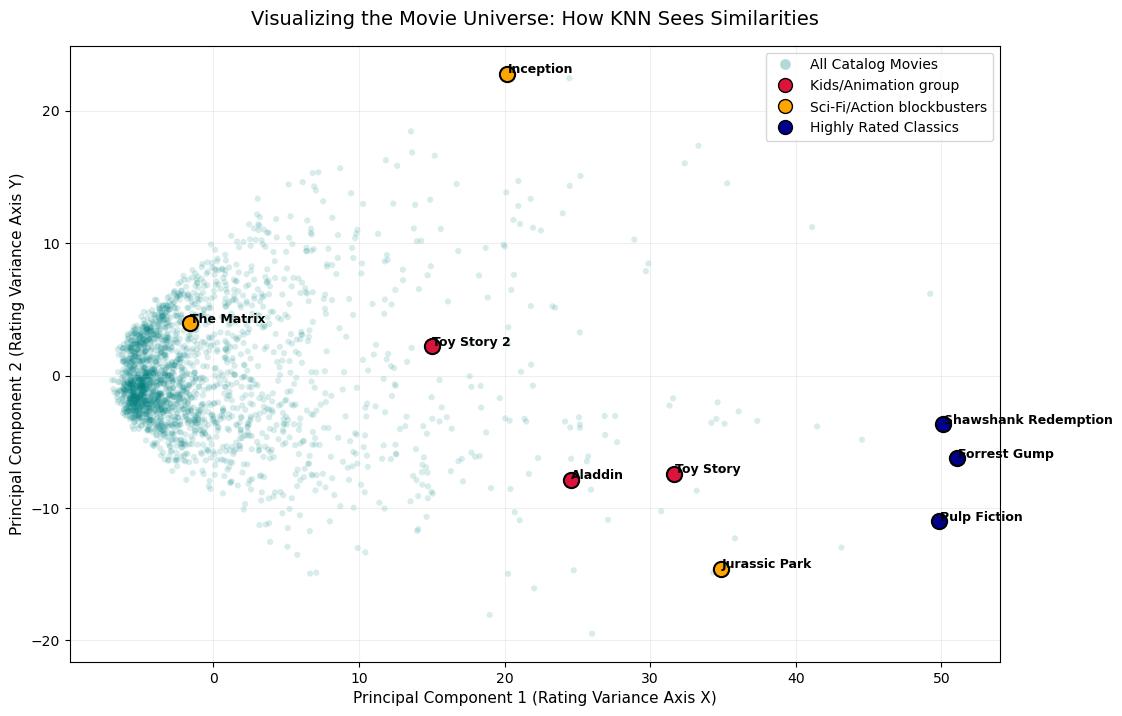

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

pca = PCA(n_components=2, random_state=42)
movie_2d = pca.fit_transform(movie_pivot.values)

plot_df = pd.DataFrame(movie_2d, columns=['Component 1', 'Component 2'])
plot_df['Title'] = movie_pivot.index

plt.figure(figsize=(12, 8))
plt.scatter(plot_df['Component 1'], plot_df['Component 2'], 
            color='teal', alpha=0.15, edgecolors='none', s=20, label='All Movies')

keywords_to_highlight = [ 
    ("Toy Story (1995)", 'crimson', "Toy Story"),
    ("Toy Story 2", 'crimson', "Toy Story 2"),
    ("Aladdin", 'crimson', "Aladdin"),
    ("Matrix", 'orange', "The Matrix"),
    ("Inception", 'orange', "Inception"),
    ("Jurassic Park", 'orange', "Jurassic Park"),
    ("Forrest Gump", 'darkblue', "Forrest Gump"),
    ("Pulp Fiction", 'darkblue', "Pulp Fiction"),
    ("Shawshank", 'darkblue', "Shawshank Redemption")
]

all_titles = plot_df['Title'].tolist()

for keyword, color, display_label in keywords_to_highlight:
    matched_titles = [t for t in all_titles if keyword.lower() in t.lower()]
    
    if matched_titles:
        actual_title = matched_titles[0]
        matched_row = plot_df[plot_df['Title'] == actual_title]
        
        plt.scatter(matched_row['Component 1'], matched_row['Component 2'], 
                    color=color, s=120, edgecolors='black', linewidths=1.5, zorder=5)
        plt.text(matched_row['Component 1'].values[0] + 0.04, 
                 matched_row['Component 2'].values[0] + 0.04, 
                 display_label, fontsize=9, weight='bold', zorder=6)

plt.title("Visualizing the Movie Universe: How KNN Sees Similarities", fontsize=14, pad=15)
plt.xlabel("Principal Component 1 (Rating Variance Axis X)", fontsize=11)
plt.ylabel('Principal Component 2 (Rating Variance Axis Y)', fontsize=11)
plt.grid(True, alpha=0.2)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='teal', alpha=0.3, markersize=8, label='All Catalog Movies'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson', markeredgecolor='black', markersize=10, label='Kids/Animation group'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markeredgecolor='black', markersize=10, label='Sci-Fi/Action blockbusters'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='darkblue', markeredgecolor='black', markersize=10, label='Highly Rated Classics')
]
plt.legend(handles=legend_elements, loc='upper right')
plt.show()